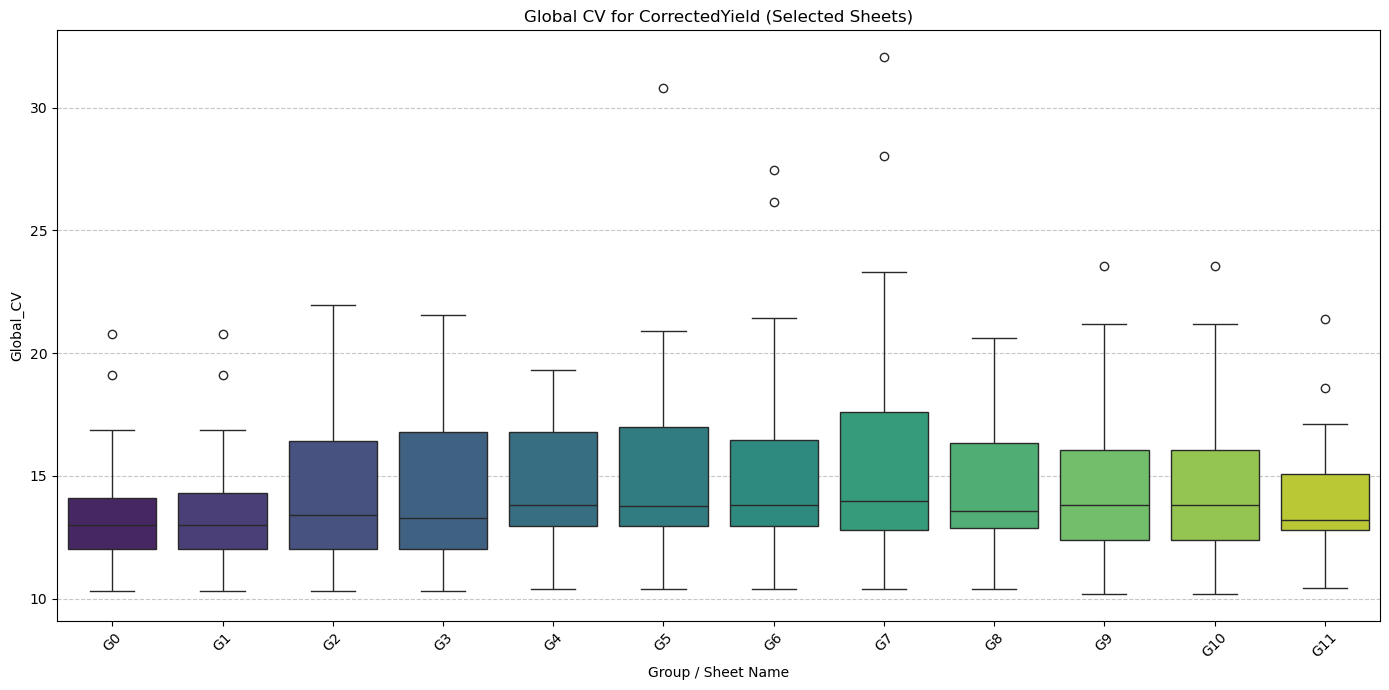

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the file path
file_path = r'C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\DeltaCV.xlsx'

# List of specific sheets identified from your image
target_sheets = [
    'G0', 'G1', 'G2', 'G3', 'G4', 
    'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11'
]

# Load only the specified sheets
excel_data = pd.read_excel(file_path, sheet_name=target_sheets)

combined_data = []

for sheet_name in target_sheets:
    df = excel_data[sheet_name]
    
    # Filter for the specific Trait
    filtered_df = df[df['Trait'] == 'CorrectedYield'].copy()
    
    # FIX: Convert Global_CV to numeric, turning errors (like " ") into NaN
    filtered_df['Global_CV'] = pd.to_numeric(filtered_df['Global_CV'], errors='coerce')
    
    # Remove rows where Global_CV is now NaN to keep the plot clean
    filtered_df = filtered_df.dropna(subset=['Global_CV'])
    
    filtered_df['SheetSource'] = sheet_name
    combined_data.append(filtered_df[['Global_CV', 'SheetSource']])

# Combine data
final_df = pd.concat(combined_data, ignore_index=True)

plt.figure(figsize=(14, 7))

# FIX: Updated Seaborn syntax (hue=x and legend=False) to remove the FutureWarning
sns.boxplot(
    x='SheetSource', 
    y='Global_CV', 
    data=final_df, 
    hue='SheetSource', 
    palette='viridis', 
    legend=False
)

plt.title('Global CV for CorrectedYield (Selected Sheets)')
plt.xlabel('Group / Sheet Name')
plt.ylabel('Global_CV')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

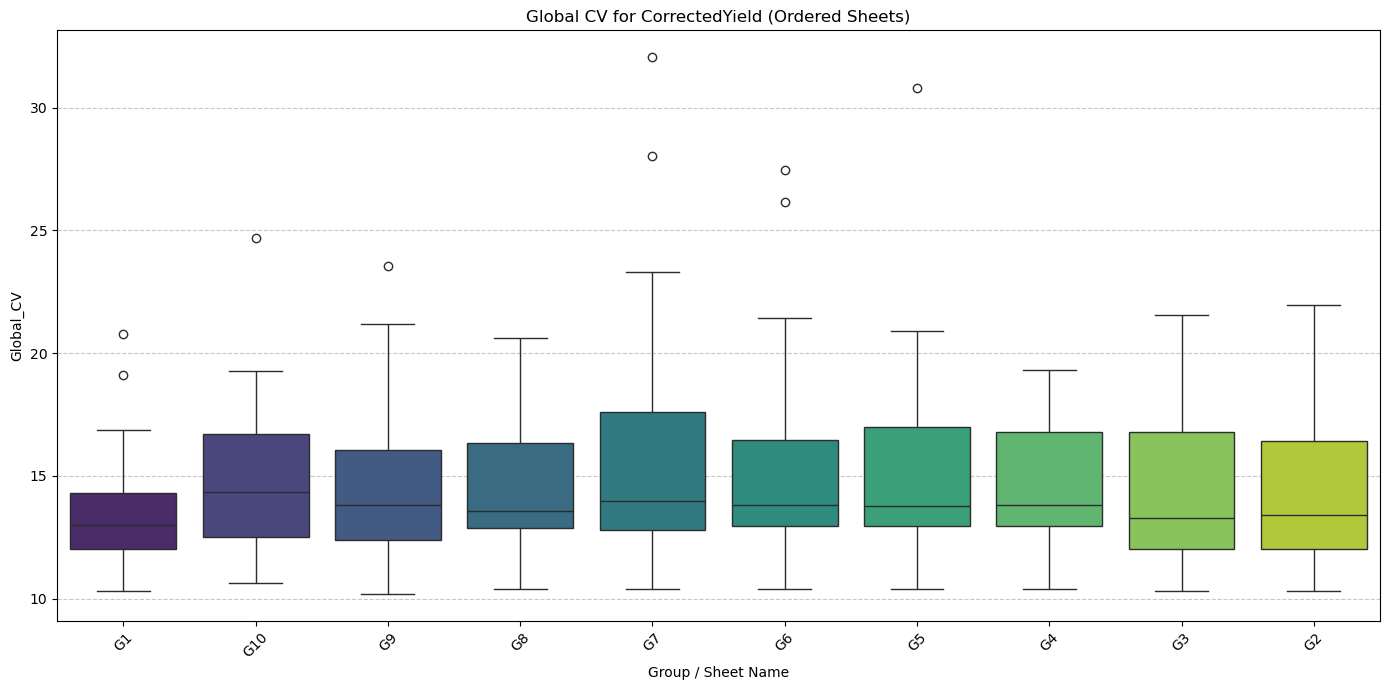

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r'C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\DeltaCV.xlsx'

# Simply rearrange this list in the exact order you want them on the X-axis
target_sheets = [
     
    'G1', 'G10','G9','G8','G7','G6','G5', 'G4', 'G3', 'G2', 
     
]

excel_data = pd.read_excel(file_path, sheet_name=target_sheets)
combined_data = []

for sheet_name in target_sheets:
    df = excel_data[sheet_name]
    filtered_df = df[df['Trait'] == 'CorrectedYield'].copy()
    
    # Handle the "space" error from before
    filtered_df['Global_CV'] = pd.to_numeric(filtered_df['Global_CV'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['Global_CV'])
    
    filtered_df['SheetSource'] = sheet_name
    combined_data.append(filtered_df[['Global_CV', 'SheetSource']])

final_df = pd.concat(combined_data, ignore_index=True)

# Important: We pass the 'target_sheets' list to the 'order' parameter 
# to ensure Seaborn respects our specific sequence.
plt.figure(figsize=(14, 7))
sns.boxplot(
    x='SheetSource', 
    y='Global_CV', 
    data=final_df, 
    order=target_sheets, 
    hue='SheetSource',
    palette='viridis',
    legend=False
)

plt.title('Global CV for CorrectedYield (Ordered Sheets)')
plt.xlabel('Group / Sheet Name')
plt.ylabel('Global_CV')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

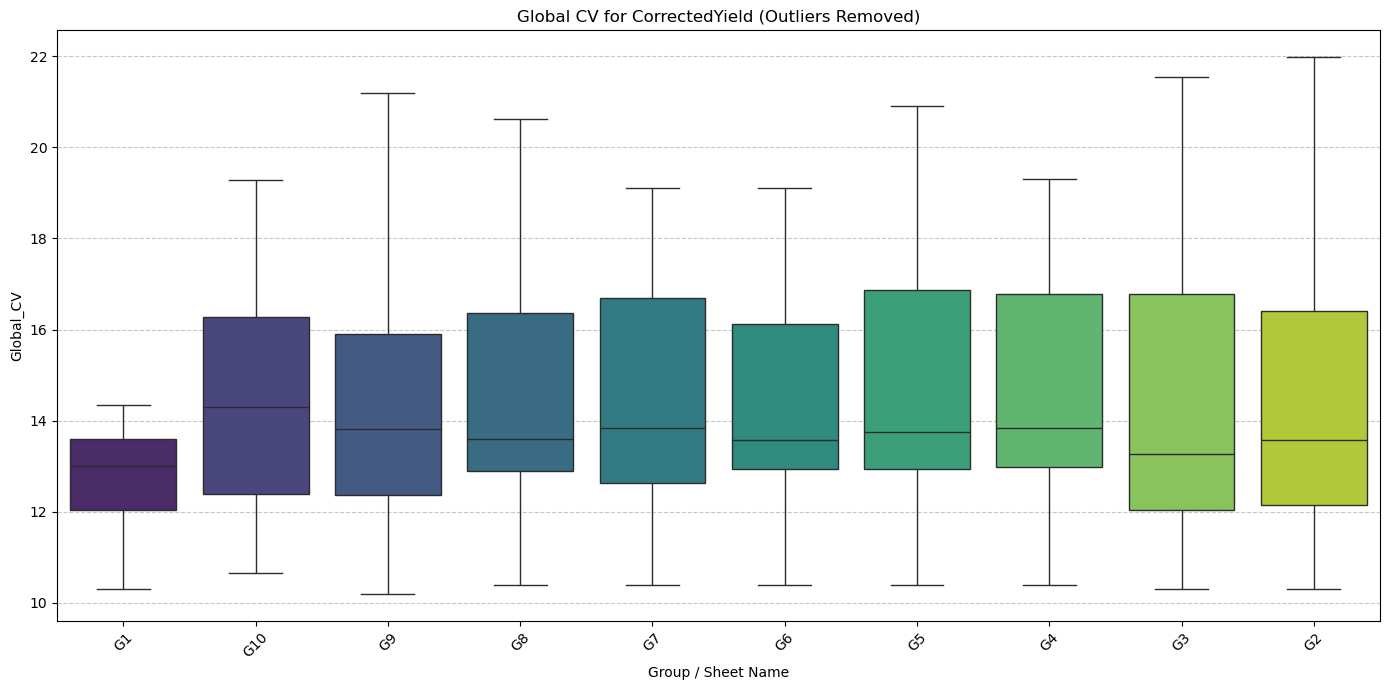

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r'C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\DeltaCV.xlsx'

# Simply rearrange this list in the exact order you want them on the X-axis
target_sheets = [
     
    'G1',  'G10', 'G9','G8','G7','G6','G5', 'G4', 'G3', 'G2', 
     
]

# Load only the specified sheets
excel_data = pd.read_excel(file_path, sheet_name=target_sheets)

combined_data = []

for sheet_name in target_sheets:
    df = excel_data[sheet_name]
    
    # Filter for the specific Trait
    filtered_df = df[df['Trait'] == 'CorrectedYield'].copy()
    
    # Clean the Global_CV column
    filtered_df['Global_CV'] = pd.to_numeric(filtered_df['Global_CV'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['Global_CV'])
    
    # --- Outlier Removal Logic (per sheet) ---
    if not filtered_df.empty:
        Q1 = filtered_df['Global_CV'].quantile(0.25)
        Q3 = filtered_df['Global_CV'].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep only the data within the bounds
        filtered_df = filtered_df[
            (filtered_df['Global_CV'] >= lower_bound) & 
            (filtered_df['Global_CV'] <= upper_bound)
        ]
    
    filtered_df['SheetSource'] = sheet_name
    combined_data.append(filtered_df[['Global_CV', 'SheetSource']])

# Combine data for plotting
final_df = pd.concat(combined_data, ignore_index=True)

# Create the visualization
plt.figure(figsize=(14, 7))
sns.boxplot(
    x='SheetSource', 
    y='Global_CV', 
    data=final_df, 
    order=target_sheets,
    hue='SheetSource',
    palette='viridis',
    legend=False,
    showfliers=False # This ensures no stray points are drawn if the calculation shifts
)

plt.title('Global CV for CorrectedYield (Outliers Removed)')
plt.xlabel('Group / Sheet Name')
plt.ylabel('Global_CV')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

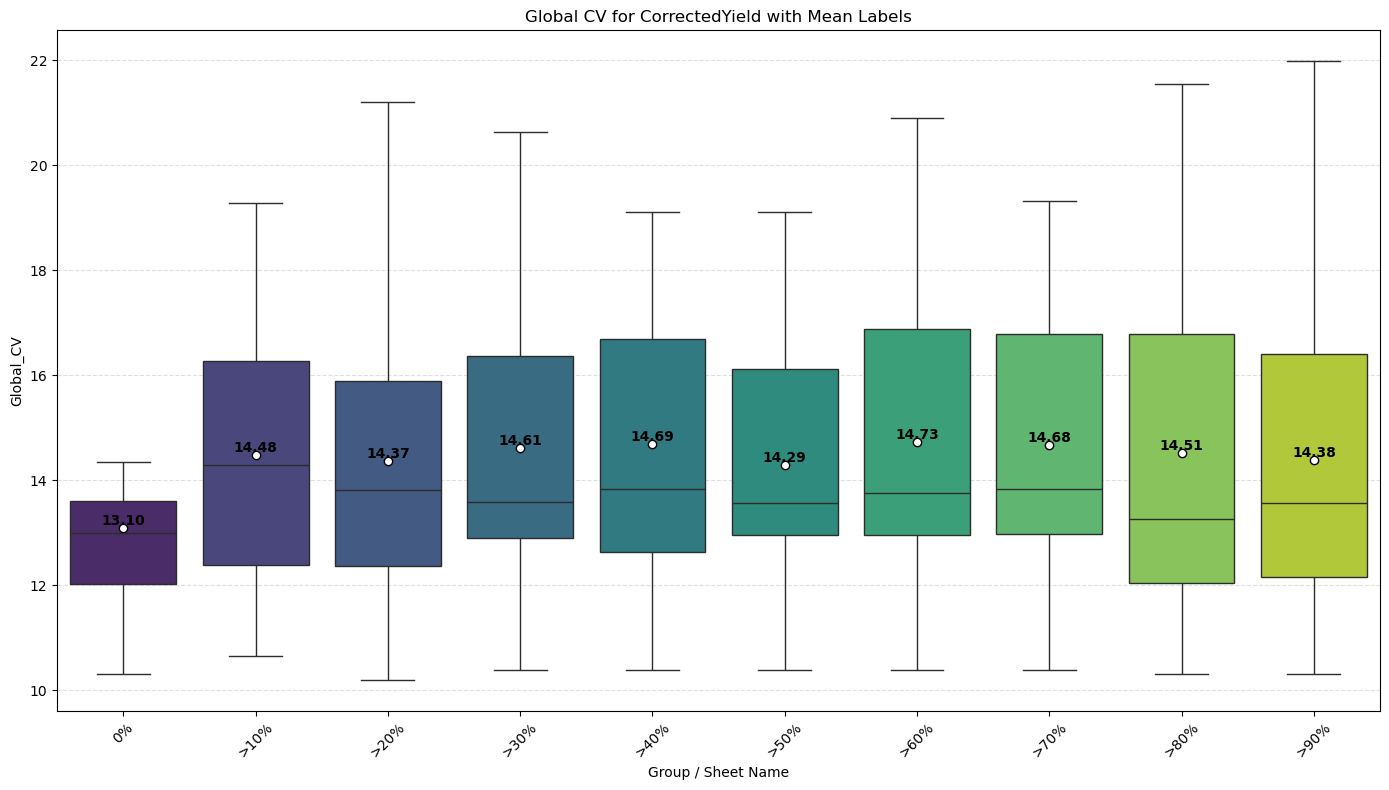

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r'C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\DeltaCV.xlsx'

# Simply rearrange this list in the exact order you want them on the X-axis
target_sheets = [
     
    '0%',  '>10%', '>20%','>30%','>40%','>50%','>60%', '>70%', '>80%', '>90%', 
     
]

excel_data = pd.read_excel(file_path, sheet_name=target_sheets)
combined_data = []

for sheet_name in target_sheets:
    df = excel_data[sheet_name]
    filtered_df = df[df['Trait'] == 'CorrectedYield'].copy()
    filtered_df['Global_CV'] = pd.to_numeric(filtered_df['Global_CV'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['Global_CV'])
    
    # Outlier Removal
    if not filtered_df.empty:
        Q1 = filtered_df['Global_CV'].quantile(0.25)
        Q3 = filtered_df['Global_CV'].quantile(0.75)
        IQR = Q3 - Q1
        filtered_df = filtered_df[
            (filtered_df['Global_CV'] >= (Q1 - 1.5 * IQR)) & 
            (filtered_df['Global_CV'] <= (Q3 + 1.5 * IQR))
        ]
    
    filtered_df['SheetSource'] = sheet_name
    combined_data.append(filtered_df[['Global_CV', 'SheetSource']])

final_df = pd.concat(combined_data, ignore_index=True)

plt.figure(figsize=(14, 8))

# Draw the boxplot
ax = sns.boxplot(
    x='SheetSource', 
    y='Global_CV', 
    data=final_df, 
    order=target_sheets,
    hue='SheetSource',
    palette='viridis',
    legend=False,
    showfliers=False,
    showmeans=True, # Adds a mean marker (usually a triangle/dot)
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"}
)

# Calculate and annotate the mean values
means = final_df.groupby('SheetSource')['Global_CV'].mean().reindex(target_sheets)

for i, sheet in enumerate(target_sheets):
    mean_val = means[sheet]
    if not pd.isna(mean_val):
        # ax.text parameters: (x-coordinate, y-coordinate, text, formatting)
        ax.text(
            i, 
            mean_val, 
            f'{mean_val:.2f}', 
            ha='center', 
            va='bottom', 
            color='black', 
            weight='bold',
            fontsize=10
        )

plt.title('Global CV for CorrectedYield with Mean Labels')
plt.xlabel('Group / Sheet Name')
plt.ylabel('Global_CV')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

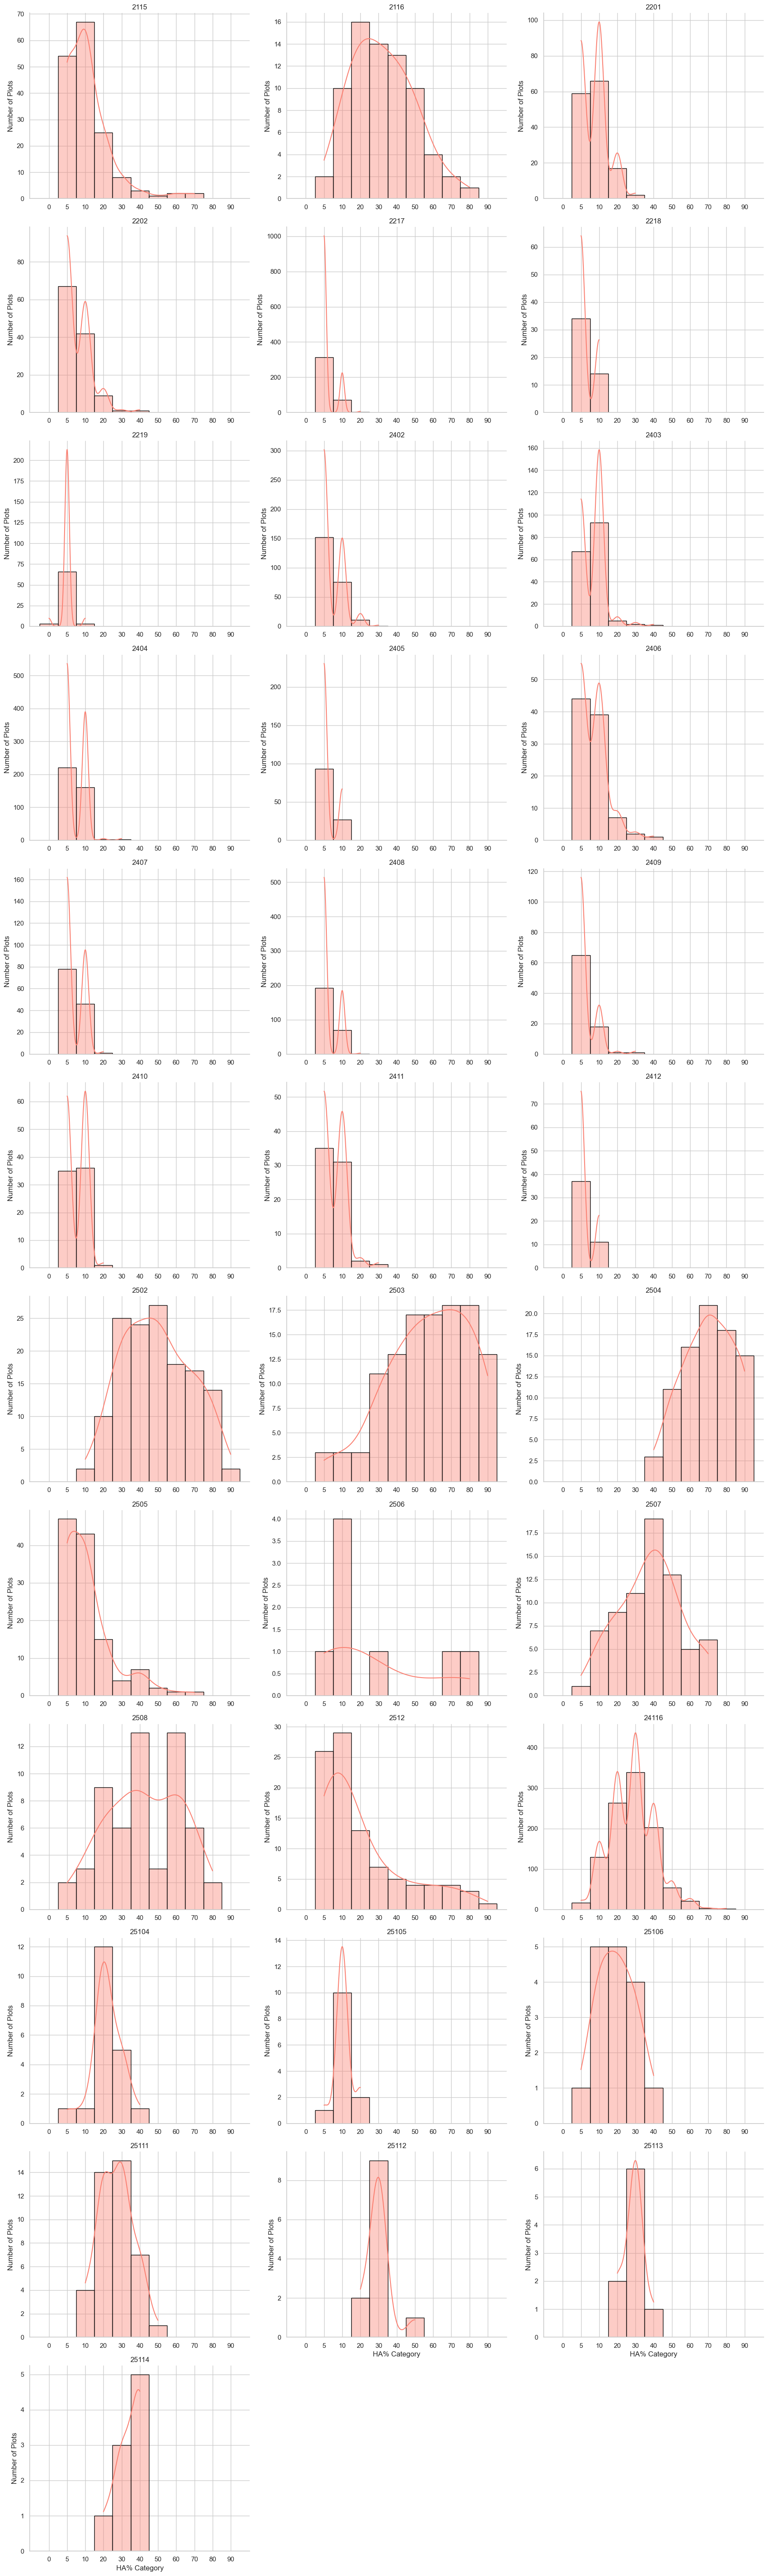

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file path
file_path = r'C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx'

# Load the dataset
df = pd.read_excel(file_path)


# Define the specific order and the new labels requested
# This ensures G1 is at the start and G2 is at the end of the sequence
old_group_order = ['G1', 'G11', 'G10', 'G9', 'G8', 'G7', 'G6', 'G5', 'G4', 'G3', 'G2']
new_group_order = ['0', '5', '10', '20', '30', '40', '50', '60', '70', '80', '90']
label_mapping = dict(zip(old_group_order, new_group_order))

# Replace the group names and enforce the categorical sequence
df['group'] = df['group'].astype(str).map(label_mapping)
df['group'] = pd.Categorical(df['group'], categories=new_group_order, ordered=True)

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the FacetGrid based on Experiment Name
g = sns.FacetGrid(
    data=df, 
    col="Experiment Name", 
    col_wrap=3, 
    height=5, 
    aspect=1.2, 
    sharex=True, 
    sharey=False
)

# Map the histogram and KDE to the grid
g.map_dataframe(
    sns.histplot, 
    x="group", 
    kde=True, 
    color="salmon", 
    alpha=0.4,
    edgecolor="black"
)

# Iterate through all subplots to force x and y labels on every single chart
for ax in g.axes.flatten():
    ax.set_xlabel("HA% Category")
    ax.set_ylabel("Number of Plots")
    # Ensure tick labels (the 0, 5, 10...) are visible on all plots
    ax.tick_params(labelbottom=True, labelleft=True)

# Use the Experiment Name for subplot titles
g.set_titles("{col_name}")

plt.tight_layout()

# Save the resulting figure with high resolution
plt.savefig('group_frequency_ordered_renamed.png', dpi=300)
plt.show()

In [38]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- CONFIGURATION & DATA LOADING ---
file_path = r'C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx'
df = pd.read_excel(file_path)

# Define the logical group order and the new numeric labels
old_group_order = ['G1', 'G11', 'G10', 'G9', 'G8', 'G7', 'G6', 'G5', 'G4', 'G3', 'G2']
new_group_order = ['0', '5', '10', '20', '30', '40', '50', '60', '70', '80', '90']
label_mapping = dict(zip(old_group_order, new_group_order))

# Pre-processing factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name', 'group']:
    if col in df.columns:
        df[col] = df[col].astype(str)

cv_results = []

# --- CALCULATION LOOP ---
# Group by Experiment (Trial)
for exp_name, exp_data in df.groupby('Experiment Name'):
    
    # Iterate through each specific group (G1, G11, etc.)
    for target_group in old_group_order:
        if target_group not in exp_data['group'].values:
            continue
            
        # Create the specialized dataset for this calculation
        # Logic: Keep CorrectedYield for target_group, set to 1 for all others
        calc_data = exp_data.copy()
        calc_data['CalcYield'] = np.where(calc_data['group'] == target_group, 
                                          calc_data['CorrectedYield'], 
                                          1.0)
        
        # Drop rows where the original yield was NaN before substitution
        calc_data = calc_data.dropna(subset=['CorrectedYield'])
        
        try:
            # Formula building
            fixed_parts = ["C(ENTRY)"]
            if calc_data['REP'].nunique() > 1:
                fixed_parts.append("C(REP)")
            formula = f"CalcYield ~ " + " + ".join(fixed_parts)
            
            # Attempt Mixed Model
            try:
                model = smf.mixedlm(formula, calc_data, groups=calc_data["REP"], re_formula="~0 + C(IBLK)")
                result = model.fit(method=["lbfgs"], maxiter=5000)
                mse = result.scale
            except:
                # Fallback to OLS
                ols_formula = f"CalcYield ~ C(ENTRY) + C(REP)" if calc_data['REP'].nunique() > 1 else f"CalcYield ~ C(ENTRY)"
                ols_result = smf.ols(ols_formula, data=calc_data).fit()
                mse = ols_result.mse_resid
            
            # Calculate CV
            mean_val = calc_data['CalcYield'].mean()
            cv_value = (np.sqrt(mse) / mean_val) * 100
            
            cv_results.append({
                'Experiment Name': exp_name,
                'Group_ID': target_group,
                'Display_Group': label_mapping[target_group],
                'CV': cv_value
            })
            
        except Exception as e:
            print(f"Skipping {exp_name} Group {target_group} due to error: {e}")

# --- PLOTTING ---
if cv_results:
    results_df = pd.DataFrame(cv_results)
    
    # Ensure categorical order for the plot
    results_df['Display_Group'] = pd.Categorical(results_df['Display_Group'], 
                                                 categories=new_group_order, 
                                                 ordered=True)

    sns.set_theme(style="whitegrid")
    
    # Create FacetGrid
    g = sns.FacetGrid(results_df, col="Experiment Name", col_wrap=3, 
                      height=5, aspect=1.2, sharex=True, sharey=False)
    
    # Map line plots (CV vs Group)
    g.map(sns.lineplot, "Display_Group", "CV", marker="o", color="teal", linewidth=2)
    
    # Force labels on every subplot
    for ax in g.axes.flatten():
        ax.set_xlabel("HA% Category")
        ax.set_ylabel("CV (%)")
        ax.tick_params(labelbottom=True, labelleft=True)
    
    g.set_titles("{col_name}")
    plt.tight_layout()
    
    plt.savefig('CV_vs_Group_by_Trial.png', dpi=300)
    plt.show()
    
    print("CV Calculation and Plotting complete.")
else:
    print("No results were generated. Check your column names and data.")

Skipping 2115 Group G11 due to error: 'REP'
Skipping 2115 Group G10 due to error: 'REP'
Skipping 2115 Group G9 due to error: 'REP'
Skipping 2115 Group G8 due to error: 'REP'
Skipping 2115 Group G7 due to error: 'REP'
Skipping 2115 Group G6 due to error: 'REP'
Skipping 2115 Group G5 due to error: 'REP'
Skipping 2115 Group G4 due to error: 'REP'
Skipping 2116 Group G11 due to error: 'REP'
Skipping 2116 Group G10 due to error: 'REP'
Skipping 2116 Group G9 due to error: 'REP'
Skipping 2116 Group G8 due to error: 'REP'
Skipping 2116 Group G7 due to error: 'REP'
Skipping 2116 Group G6 due to error: 'REP'
Skipping 2116 Group G5 due to error: 'REP'
Skipping 2116 Group G4 due to error: 'REP'
Skipping 2116 Group G3 due to error: 'REP'
Skipping 2201 Group G11 due to error: 'REP'
Skipping 2201 Group G10 due to error: 'REP'
Skipping 2201 Group G9 due to error: 'REP'
Skipping 2201 Group G8 due to error: 'REP'
Skipping 2202 Group G11 due to error: 'REP'
Skipping 2202 Group G10 due to error: 'REP'
Ski

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values

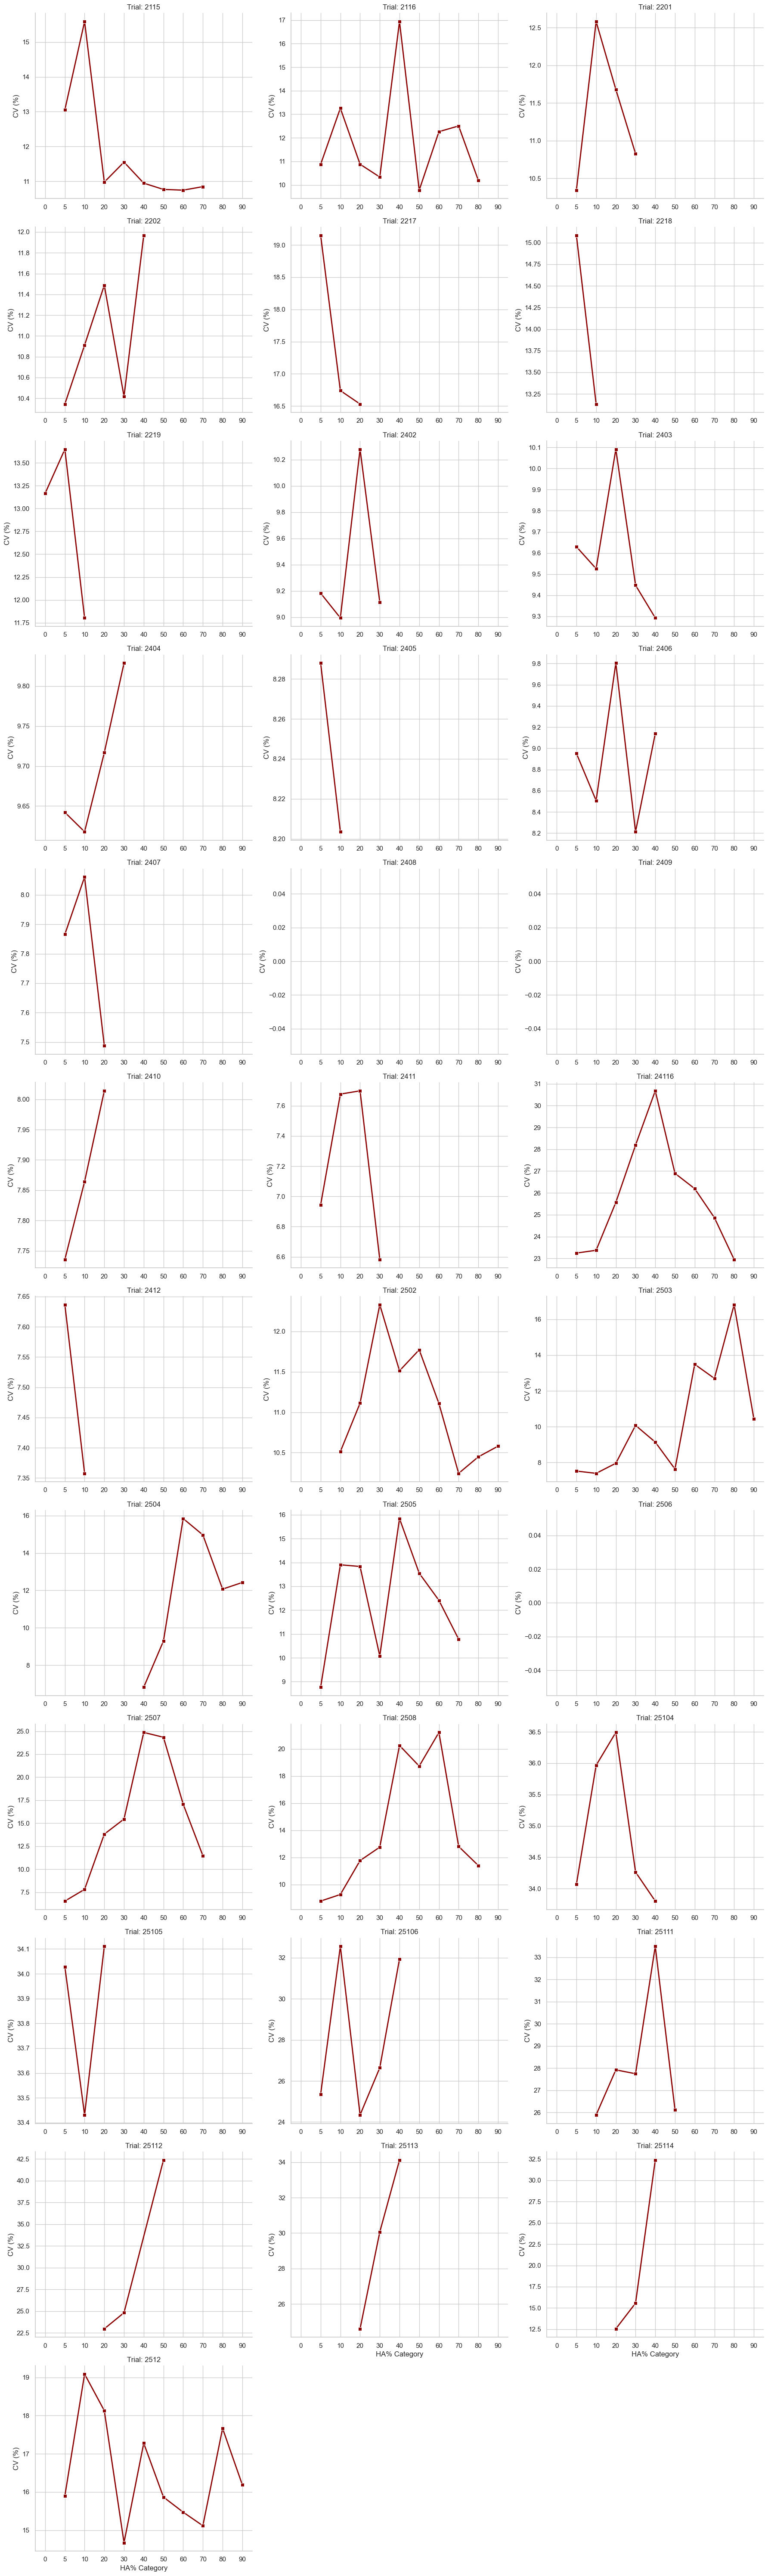

In [45]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- CONFIGURATION & DATA LOADING ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
df = pd.read_excel(file_path)

# Standardize column names (remove spaces and handle the underscore issue)
df.columns = df.columns.str.strip()
# Create a mapping to ensure we use the correct names regardless of underscores
column_map = {
    'Corrected_Yield': 'CorrectedYield',
    'Uncorrected_Yield': 'UncorrectedYield'
}
df = df.rename(columns=column_map)

# Verify columns exist before proceeding
required = ['CorrectedYield', 'UncorrectedYield', 'group', 'Experiment Name']
missing = [col for col in required if col not in df.columns]
if missing:
    raise KeyError(f"Missing columns in Excel file: {missing}. Available: {list(df.columns)}")

# Define the logical group order and the new numeric labels
old_group_order = ['G1', 'G11', 'G10', 'G9', 'G8', 'G7', 'G6', 'G5', 'G4', 'G3', 'G2']
new_group_order = ['0', '5', '10', '20', '30', '40', '50', '60', '70', '80', '90']
label_mapping = dict(zip(old_group_order, new_group_order))

# Pre-processing factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name', 'group']:
    if col in df.columns:
        df[col] = df[col].astype(str)

cv_results = []

# --- CALCULATION LOOP ---
for exp_name, exp_data in df.groupby('Experiment Name'):
    
    for target_group in old_group_order:
        if target_group not in exp_data['group'].values:
            continue
            
        # Create the specialized dataset for this calculation
        calc_data = exp_data.copy()
        
        # Logic: CorrectedYield for target_group, UncorrectedYield for all others
        calc_data['CalcYield'] = np.where(
            calc_data['group'] == target_group, 
            calc_data['CorrectedYield'], 
            calc_data['UncorrectedYield']
        )
        
        # Drop rows where the resulting yield is NaN
        calc_data = calc_data.dropna(subset=['CalcYield'])
        
        try:
            # Formula building
            fixed_parts = ["C(ENTRY)"]
            if calc_data['REP'].nunique() > 1:
                fixed_parts.append("C(REP)")
            formula = f"CalcYield ~ " + " + ".join(fixed_parts)
            
            # Attempt Mixed Model
            try:
                model = smf.mixedlm(formula, calc_data, groups=calc_data["REP"], re_formula="~0 + C(IBLK)")
                result = model.fit(method=["lbfgs"], maxiter=5000)
                mse = result.scale
            except:
                # Fallback to OLS
                ols_formula = f"CalcYield ~ C(ENTRY) + C(REP)" if calc_data['REP'].nunique() > 1 else f"CalcYield ~ C(ENTRY)"
                ols_result = smf.ols(ols_formula, data=calc_data).fit()
                mse = ols_result.mse_resid
            
            # Calculate CV
            mean_val = calc_data['CalcYield'].mean()
            cv_value = (np.sqrt(mse) / mean_val) * 100
            
            cv_results.append({
                'Experiment Name': exp_name,
                'Group_ID': target_group,
                'Display_Group': label_mapping[target_group],
                'CV': cv_value
            })
            
        except Exception as e:
            continue

# --- PLOTTING ---
if cv_results:
    results_df = pd.DataFrame(cv_results)
    results_df['Display_Group'] = pd.Categorical(results_df['Display_Group'], categories=new_group_order, ordered=True)

    sns.set_theme(style="whitegrid")
    g = sns.FacetGrid(results_df, col="Experiment Name", col_wrap=3, height=5, aspect=1.2, sharex=True, sharey=False)
    
    g.map(sns.lineplot, "Display_Group", "CV", marker="s", color="darkred", linewidth=2)
    
    for ax in g.axes.flatten():
        ax.set_xlabel("HA% Category")
        ax.set_ylabel("CV (%)")
        ax.tick_params(labelbottom=True, labelleft=True)
    
    g.set_titles("Trial: {col_name}")
    plt.tight_layout()
    plt.savefig('CV_Corrected_vs_Uncorrected_Final.png', dpi=300)
    plt.show()
else:
    print("No results generated. Double-check column naming in your Excel file.")

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values

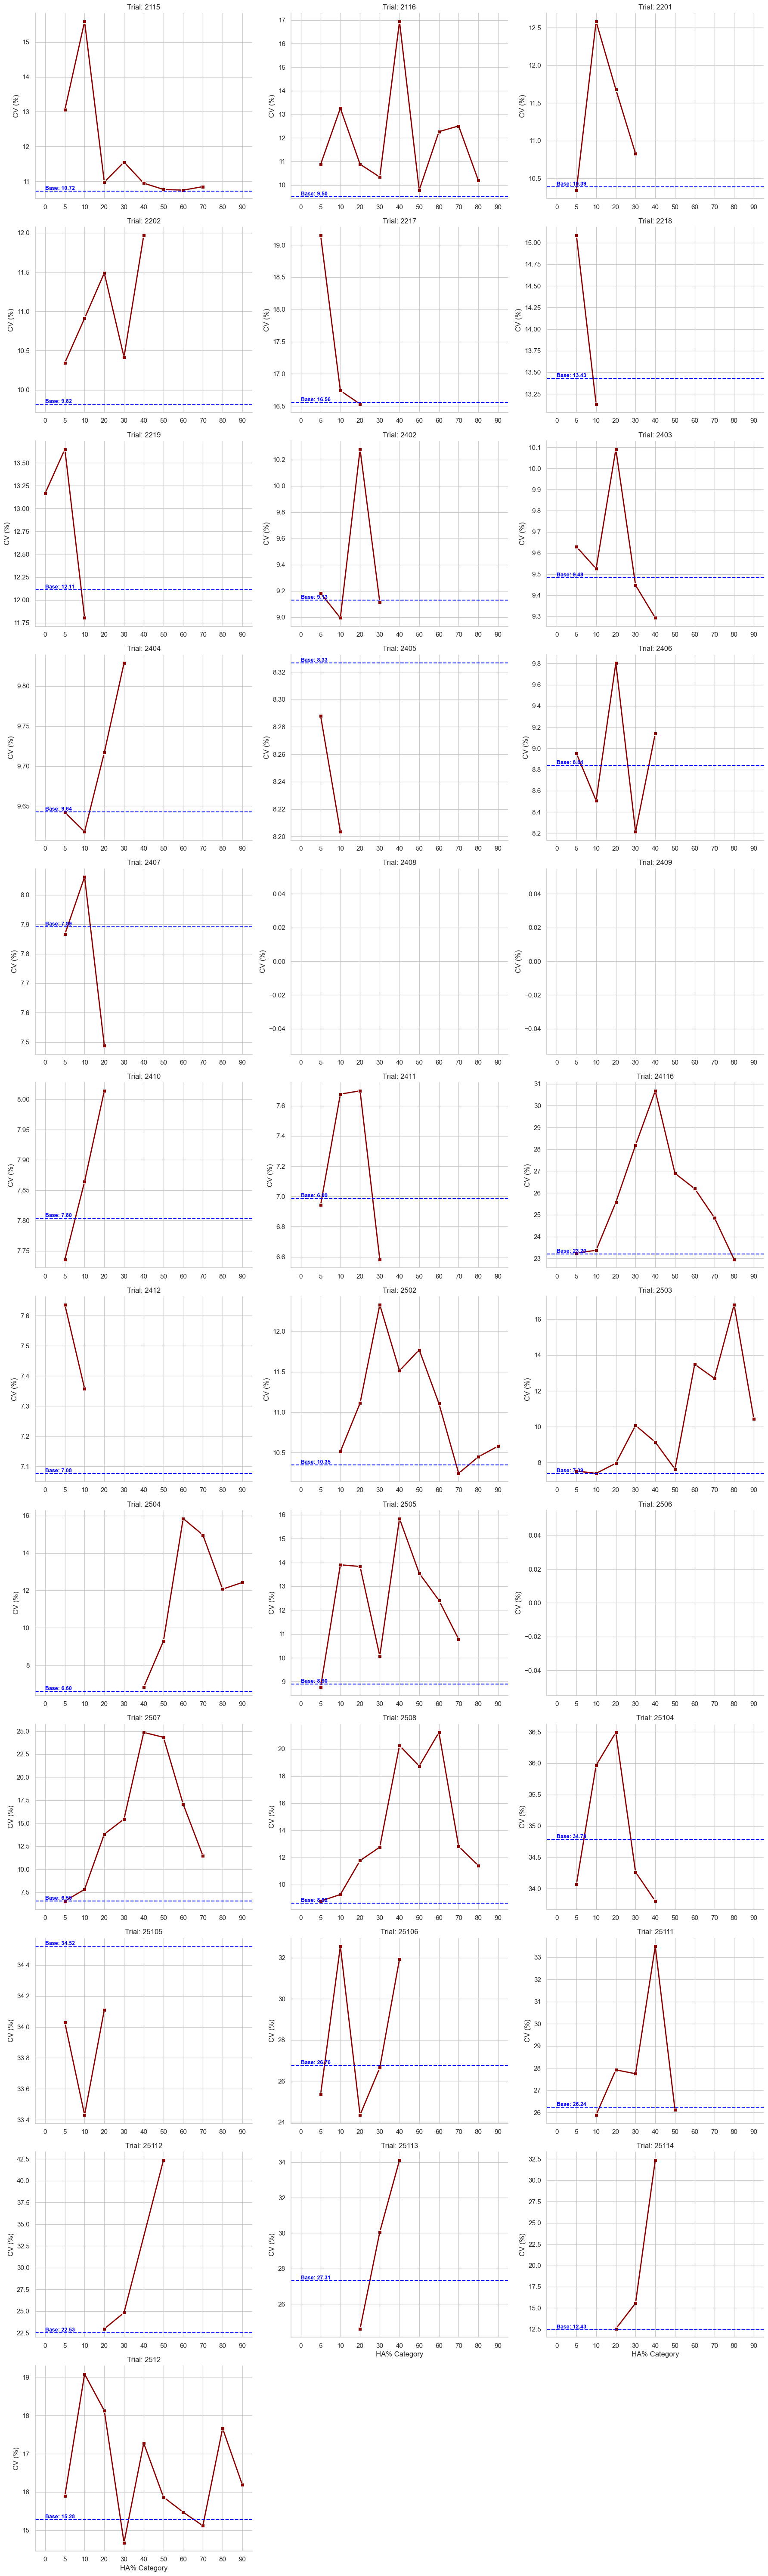

Analysis complete. The blue dashed line represents the original Uncorrected CV for the trial.


In [46]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- CONFIGURATION & DATA LOADING ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip()
column_map = {'Corrected_Yield': 'CorrectedYield', 'Uncorrected_Yield': 'UncorrectedYield'}
df = df.rename(columns=column_map)

# Define logical orders
old_group_order = ['G1', 'G11', 'G10', 'G9', 'G8', 'G7', 'G6', 'G5', 'G4', 'G3', 'G2']
new_group_order = ['0', '5', '10', '20', '30', '40', '50', '60', '70', '80', '90']
label_mapping = dict(zip(old_group_order, new_group_order))

# Pre-processing factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name', 'group']:
    if col in df.columns:
        df[col] = df[col].astype(str)

cv_results = []
baseline_cvs = {}

# --- CALCULATION LOOP ---
for exp_name, exp_data in df.groupby('Experiment Name'):
    
    # 1. Calculate Baseline CV (Uncorrected Yield for the whole trial)
    try:
        baseline_data = exp_data.dropna(subset=['UncorrectedYield'])
        b_fixed = ["C(ENTRY)"]
        if baseline_data['REP'].nunique() > 1: b_fixed.append("C(REP)")
        b_formula = f"UncorrectedYield ~ " + " + ".join(b_fixed)
        
        try:
            b_model = smf.mixedlm(b_formula, baseline_data, groups=baseline_data["REP"], re_formula="~0 + C(IBLK)")
            b_res = b_model.fit(method=["lbfgs"], maxiter=5000)
            b_mse = b_res.scale
        except:
            b_ols = smf.ols(b_formula, data=baseline_data).fit()
            b_mse = b_ols.mse_resid
            
        baseline_cvs[exp_name] = (np.sqrt(b_mse) / baseline_data['UncorrectedYield'].mean()) * 100
    except:
        baseline_cvs[exp_name] = np.nan

    # 2. Calculate Group-Specific CVs
    for target_group in old_group_order:
        if target_group not in exp_data['group'].values:
            continue
            
        calc_data = exp_data.copy()
        calc_data['CalcYield'] = np.where(
            calc_data['group'] == target_group, 
            calc_data['CorrectedYield'], 
            calc_data['UncorrectedYield']
        )
        calc_data = calc_data.dropna(subset=['CalcYield'])
        
        try:
            fixed_parts = ["C(ENTRY)"]
            if calc_data['REP'].nunique() > 1: fixed_parts.append("C(REP)")
            formula = f"CalcYield ~ " + " + ".join(fixed_parts)
            
            try:
                model = smf.mixedlm(formula, calc_data, groups=calc_data["REP"], re_formula="~0 + C(IBLK)")
                result = model.fit(method=["lbfgs"], maxiter=5000)
                mse = result.scale
            except:
                ols_formula = f"CalcYield ~ C(ENTRY) + C(REP)" if calc_data['REP'].nunique() > 1 else f"CalcYield ~ C(ENTRY)"
                ols_result = smf.ols(ols_formula, data=calc_data).fit()
                mse = ols_result.mse_resid
            
            cv_results.append({
                'Experiment Name': exp_name,
                'Group_ID': target_group,
                'Display_Group': label_mapping[target_group],
                'CV': (np.sqrt(mse) / calc_data['CalcYield'].mean()) * 100
            })
        except:
            continue

# --- PLOTTING ---
if cv_results:
    results_df = pd.DataFrame(cv_results)
    results_df['Display_Group'] = pd.Categorical(results_df['Display_Group'], categories=new_group_order, ordered=True)

    sns.set_theme(style="whitegrid")
    g = sns.FacetGrid(results_df, col="Experiment Name", col_wrap=3, height=5, aspect=1.2, sharex=True, sharey=False)
    
    # Plot the calculated Group CVs
    g.map(sns.lineplot, "Display_Group", "CV", marker="s", color="darkred", linewidth=2, label="Corrected Group CV")
    
    # Add the Uncorrected Baseline CV as a horizontal line for each subplot
    for ax in g.axes.flatten():
        title = ax.get_title().replace("Experiment Name = ", "")
        if title in baseline_cvs:
            b_val = baseline_cvs[title]
            ax.axhline(b_val, color='blue', linestyle='--', linewidth=1.5, label='Total Uncorrected CV')
            # Add text label for the baseline value
            ax.text(0, b_val, f'Base: {b_val:.2f}', color='blue', va='bottom', fontweight='bold', fontsize=9)
        
        ax.set_xlabel("HA% Category")
        ax.set_ylabel("CV (%)")
        ax.tick_params(labelbottom=True, labelleft=True)
    
    g.set_titles("Trial: {col_name}")
    plt.tight_layout()
    plt.savefig('CV_Comparison_with_Baseline.png', dpi=300)
    plt.show()

    print("Analysis complete. The blue dashed line represents the original Uncorrected CV for the trial.")

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\s

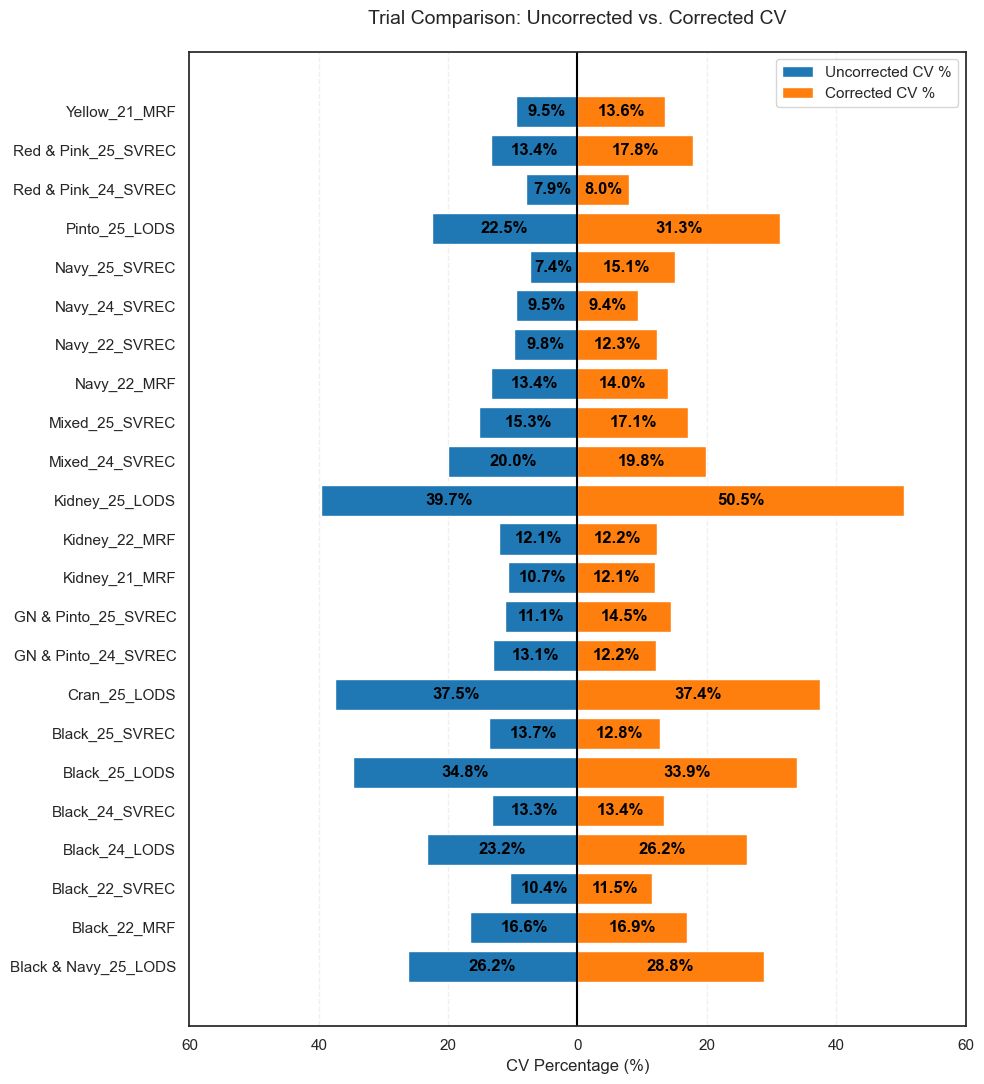

Comparison plot generated. Blue (left) is Uncorrected, Orange (right) is Corrected.


In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated_rename.xlsx"
df = pd.read_excel(file_path)

df.columns = df.columns.str.strip()
df = df.rename(columns={'Corrected_Yield': 'CorrectedYield', 'Uncorrected_Yield': 'UncorrectedYield'})

for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df.columns:
        df[col] = df[col].astype(str)

comparison_results = []

def calculate_cv(data, trait):
    """Helper function to calculate CV using the mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: return np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        return (np.sqrt(mse) / analysis_data[trait].mean()) * 100
    except:
        return np.nan

# --- CALCULATION ---
for exp_name, exp_data in df.groupby('Experiment Name'):
    uncorr_cv = calculate_cv(exp_data, 'UncorrectedYield')
    corr_cv = calculate_cv(exp_data, 'CorrectedYield')
    
    comparison_results.append({
        'Trial': exp_name,
        'Uncorrected': uncorr_cv,
        'Corrected': corr_cv
    })

results_df = pd.DataFrame(comparison_results).dropna()

# --- VISUALIZATION (Tornado/Back-to-Back Chart) ---
plt.figure(figsize=(10, 11))
sns.set_theme(style="white")

# Plotting Uncorrected on the left (negative values to push left)
bar_uncorr = plt.barh(results_df['Trial'], -results_df['Uncorrected'], color='#1f77b4', label='Uncorrected CV %')
# Plotting Corrected on the right
bar_corr = plt.barh(results_df['Trial'], results_df['Corrected'], color='#ff7f0e', label='Corrected CV %')

# Add labels inside/on the bars
for i, (u, c) in enumerate(zip(results_df['Uncorrected'], results_df['Corrected'])):
    plt.text(-u/2, i, f'{u:.1f}%', va='center', ha='center', color='black', fontweight='bold')
    plt.text(c/2, i, f'{c:.1f}%', va='center', ha='center', color='black', fontweight='bold')

# Formatting
plt.axvline(0, color='black', linewidth=1.5) # Center line
plt.xlabel('CV Percentage (%)')
plt.title('Trial Comparison: Uncorrected vs. Corrected CV', fontsize=14, pad=20)
plt.legend(loc='upper right')

# Adjust x-axis to show absolute values (removing the negative sign for display)
max_val = max(results_df['Uncorrected'].max(), results_df['Corrected'].max()) + 5
plt.xlim(-max_val, max_val)
ticks = plt.xticks()[0]
plt.xticks(ticks, [str(int(abs(t))) for t in ticks])

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('Trial_CV_Tornado_Plot1.png', dpi=300)
plt.show()

print("Comparison plot generated. Blue (left) is Uncorrected, Orange (right) is Corrected.")